# What drives the block-LE vs. dense-LE disagreement?

`dag_vs_true_le_distance.ipynb` found that the block-diagonal log-Euclidean distance
(`hc.compute_ground_truth`: independent `log_spd` per block, summed `‖·‖/√b`) and the dense
whole-matrix LE (`hc.compute_ground_truth_whole_matrix`: one `log_spd` of the full gene × gene
matrix, `‖·‖/√p`) barely agree: across-query Pearson r ≈ −0.25, and the two never pick the same
nearest-neighbour tile (0/100).

The candidate explanations tested here:

1. **Negative off-diagonal entries.** Test: zero the negatives, or take |corr| as the index
   does when it clusters genes on 1 − |R| (`metrics.spd_to_ultrametric`, `index._topk_graph_from_corr`).
2. **Rank deficiency / the ε floor.** Tiles hold ≤ 200 cells (`max_pts=200`) but p = 377 genes, and
   `_cov_ml` adds only a 1e-6 ridge. Every full covariance therefore has ≥ 178 eigenvalues pinned at 1e-6,
   and `log_spd` maps each one to log(1e-6) ≈ −13.8. Many Xenium genes also have zero variance within a tile.
   Test: shrink toward a scaled identity before the log.
3. **Aggregation.** The block metric *sums* per-block norms. Control: √(Σ_b‖·‖²)/√p.
4. **Off-block entries per se.** Control: zero every off-block entry of the covariance before the dense log.
   The dense metric then sees only the blocks.

For every variant, **both** metrics are computed from the *same* transformed matrix. Agreement is measured
per query, across all 683 training tiles. No library code is modified.

In [1]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "8")

import sys
import time
from pathlib import Path

PROJECT_ROOT = Path("/home/NAShome/ghoss18/spindle_dev")
for p in (PROJECT_ROOT / "src", PROJECT_ROOT, PROJECT_ROOT / "benchmarks"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

import benchmarks.index.build_indexes as bidx

OUT_DIR = PROJECT_ROOT / "HS_notebooks"
print("Imports OK.")

Imports OK.


## 1. Same split and block layout as `dag_vs_true_le_distance.ipynb`

The dataset is kidney, with seed 73, 100 held-out tiles and resolution 0.2. Only `run_index` is needed, for
`data.perm_list` / `data.block_dict`; the DAG itself is not used. Every matrix is permuted into block order once, up
front. Permutation changes neither LE distance.

In [2]:
DATASET_PATH = Path("/home/NAShome/sarkah1/shared_data/insitupy_demo_data_xenium/xenium_human_kidney_nondiseased.h5ad")
adata, genes_work, train_tiles, train_tile_covs, test_tiles, test_tile_covs, train_idx, test_idx = bidx.load_and_split_data(
    DATASET_PATH, test_ratio=0.05, seed=73, n_holdout=100,
)
data, _ = bidx.run_index(train_tiles, train_tile_covs, genes_work, adata,
                         resolution=0.2, min_final_size=15, max_niche_size=1000)

niches = sorted(set(int(c) for c in data.labels))
assert len(niches) == 1, "this analysis assumes the single-niche kidney build"
perm = np.asarray(data.perm_list[0])
block_runs = [tuple(r) for r in data.block_dict[0]]
P = np.ix_(perm, perm)

train = [c["cov"].astype(np.float64)[P] for c in train_tile_covs]
test = [c["cov"].astype(np.float64)[P] for c in test_tile_covs]
n_train = np.array([c["n"] for c in train_tile_covs])
n_test = np.array([c["n"] for c in test_tile_covs])
p = train[0].shape[0]
FLOOR = 1e-6   # _cov_ml's ridge; also used as the eigenvalue floor for every variant below

block_mask = np.zeros((p, p), dtype=bool)
for s, e in block_runs:
    block_mask[s:e, s:e] = True
print(f"p = {p} genes, {len(block_runs)} blocks (sizes {min(e - s for s, e in block_runs)}-{max(e - s for s, e in block_runs)}), "
      f"{len(train)} train / {len(test)} test tiles, cells per tile {np.concatenate([n_train, n_test]).min()}-{np.concatenate([n_train, n_test]).max()}")

[2026-09-28 22:38:25,322] INFO spindle_dev.preprocessing: build_quadtree_tiles: dropping 27 low-density tile(s) (772 spot(s) total) whose density is far below typical.


Reading data from /home/NAShome/sarkah1/shared_data/insitupy_demo_data_xenium/xenium_human_kidney_nondiseased.h5ad...
Preparing data for indexing...


[2026-09-28 22:38:25,819] INFO spindle_dev.index: Clustering SPD-s using 'tree' distance.


[2026-09-28 22:38:25,832] INFO spindle_dev.index: Building ultrametric features from SPD matrices.


Total tiles: 783 | Training/Indexed: 683 | Held out/Testing: 100 (seed=73, n_holdout=100)


...

[2026-09-28 22:38:31,643] INFO spindle_dev.index: Computing mean correlation matrix for cluster 0


[2026-09-28 22:38:31,869] INFO spindle_dev.index: Finding adaptive block runs for cluster 0


[2026-09-28 22:38:31,970] INFO spindle_dev.index:  Chose t=0.9179402517379516 resulting in 193 blocks instead of 185 blocks would have gotten by default


[2026-09-28 22:38:31,988] INFO spindle_dev.index:  Final block runs for cluster 0: 18 blocks.


p = 377 genes, 18 blocks (sizes 15-41), 683 train / 100 test tiles, cells per tile 27-199


## 2. How rank-deficient are the tile covariances?

For each of the 783 tiles, this counts:
- eigenvalues within 10× of the 1e-6 floor, for the full matrix and summed over the 18 blocks;
- genes with (near-)zero variance in that tile;
- how many of the 18 blocks are rank-deficient.

In [3]:
def _rank_diag(C):
    w = np.linalg.eigvalsh(C)
    block_eigs = [np.linalg.eigvalsh(C[s:e, s:e]) for s, e in block_runs]
    return {
        "n_floor_eigs_full": int((w < 10 * FLOOR).sum()),
        "n_zero_var_genes": int((np.diag(C) < 10 * FLOOR).sum()),
        "n_rank_def_blocks": int(sum((we < 10 * FLOOR).any() for we in block_eigs)),
        "n_floor_eigs_blocks": int(sum((we < 10 * FLOOR).sum() for we in block_eigs)),
    }

rank_df = pd.DataFrame([_rank_diag(C) for C in train + test])
rank_df["n_cells"] = np.concatenate([n_train, n_test])
rank_df.to_csv(OUT_DIR / "block_vs_dense_rank_diagnostics.csv", index=False)

always_expressed = int((np.min([np.diag(C) for C in train + test], axis=0) > 10 * FLOOR).sum())
print(f"Genes with non-zero variance in EVERY tile: {always_expressed} / {p}")
rank_df.describe().loc[["mean", "min", "50%", "max"]]

Genes with non-zero variance in EVERY tile: 32 / 377


,n_floor_eigs_full,n_zero_var_genes,n_rank_def_blocks,n_floor_eigs_blocks,n_cells
mean,254.394636,79.633461,13.355045,82.538953,123.609195
min,179.000000,18.000000,5.000000,19.000000,27.000000
50%,252.000000,75.000000,13.000000,77.000000,126.000000
max,351.000000,196.000000,18.000000,212.000000,199.000000


## 3. Transform variants: which change brings the two metrics into agreement?

Each transform is applied to the permuted matrix before any log. The two metrics are then:
- **block**: `log_spd` of each diagonal block of the transformed matrix, `Σ_b ‖ΔL_b‖/√b` (as `compute_ground_truth` computes it);
- **dense**: one `log_spd` of the whole transformed matrix, `‖ΔL‖/√p`.

"neg→0" and |corr| are generally **not PSD**. `frac_neg_eigs` / `min_eig` report how far from PSD they are, before the
eigenvalues are clipped at the same 1e-6 floor used everywhere else. The shrinkage target is `mean(diag)·I`.

Metrics reported:
- `rho_*`: per-query Spearman between block and dense distances across all 683 train tiles.
- `rho_aggctrl_vs_dense`: the same, with the block metric re-aggregated as √(Σ‖ΔL_b‖²)/√p.
- `top1_agree`: the block and dense nearest neighbours are the same tile.
- `median_blockrank_of_denseNN`: where the dense NN falls in the block ranking (0 = first).
- `acrossQ_pearson`: Part A's across-query statistic, block vs. dense distance to the block NN.

In [4]:
def corr(C):
    d = np.sqrt(np.clip(np.diag(C), FLOOR, None))
    R = np.clip(C / np.outer(d, d), -1, 1)
    np.fill_diagonal(R, 1.0)
    return R

def shrink(M, a):
    return (1 - a) * M + a * np.mean(np.diag(M)) * np.eye(M.shape[0])

def neg0(M):
    M = M.copy(); M[M < 0] = 0; return M

def neg0_offblock(M):
    M = M.copy(); M[(M < 0) & ~block_mask] = 0; return M

VARIANTS = {
    "raw cov (baseline)":          lambda C: C,
    "corr":                        corr,
    "corr, neg->0":                lambda C: neg0(corr(C)),
    "corr, off-block neg->0":      lambda C: neg0_offblock(corr(C)),
    "|corr|":                      lambda C: np.abs(corr(C)),
    "cov, off-block->0 (control)": lambda C: np.where(block_mask, C, 0.0),
    "cov shrunk a=0.01":           lambda C: shrink(C, 0.01),
    "cov shrunk a=0.1":            lambda C: shrink(C, 0.1),
    "cov shrunk a=0.3":            lambda C: shrink(C, 0.3),
    "corr shrunk a=0.1":           lambda C: shrink(corr(C), 0.1),
    "|corr| shrunk a=0.1":         lambda C: shrink(np.abs(corr(C)), 0.1),
    "corr neg->0 shrunk a=0.1":    lambda C: shrink(neg0(corr(C)), 0.1),
}

def logm(M, floor=FLOOR):
    w, V = np.linalg.eigh(0.5 * (M + M.T))
    return (V * np.log(np.maximum(w, floor))) @ V.T, (w < 0).mean(), w.min()

def sqdist(A, B):
    return np.maximum((A * A).sum(1)[:, None] + (B * B).sum(1)[None, :] - 2 * A @ B.T, 0)

def both_metrics(f):
    # Returns block (nq x nt), dense, block re-aggregated as sqrt(sum sq)/sqrt(p), PSD stats, off-block log energy.
    nq = len(test)
    dense_logs, block_logs, negs, wmins = [], [[] for _ in block_runs], [], []
    for C in test + train:
        M = f(C)
        L, neg, wmin = logm(M)
        dense_logs.append(L.ravel()); negs.append(neg); wmins.append(wmin)
        for b, (s, e) in enumerate(block_runs):
            block_logs[b].append(logm(M[s:e, s:e])[0].ravel())
    D = np.stack(dense_logs)
    dense = np.sqrt(sqdist(D[:nq], D[nq:])) / np.sqrt(p)
    blk_sq = np.stack([sqdist(np.stack(B)[:nq], np.stack(B)[nq:]) for B in block_logs])
    sizes = np.array([e - s for s, e in block_runs])[:, None, None]
    block = (np.sqrt(blk_sq) / np.sqrt(sizes)).sum(0)
    block_agg = np.sqrt(blk_sq.sum(0)) / np.sqrt(p)
    # share of the (query) full log's energy not explained by its independently-logged blocks
    off = []
    for i in range(nq):
        Lb = np.zeros((p, p))
        for b, (s, e) in enumerate(block_runs):
            Lb[s:e, s:e] = block_logs[b][i].reshape(e - s, e - s)
        Lf = D[i].reshape(p, p)
        off.append(np.sum((Lf - Lb) ** 2) / np.sum(Lf ** 2))
    return block, dense, block_agg, np.mean(negs), np.min(wmins), np.mean(off)

K_LIST = [1, 5, 10, 20, 50, 100]
rows, recall_rows, store = [], [], {}
nq = len(test)
for name, f in VARIANTS.items():
    t0 = time.time()
    block, dense, block_agg, neg, wmin, off = both_metrics(f)
    store[name] = (block, dense)
    rho = np.array([stats.spearmanr(block[i], dense[i]).statistic for i in range(nq)])
    rho_agg = np.array([stats.spearmanr(block_agg[i], dense[i]).statistic for i in range(nq)])
    bnn, dnn = block.argmin(1), dense.argmin(1)
    rank_of_dnn = np.argsort(np.argsort(block, 1), 1)[np.arange(nq), dnn]
    rows.append({
        "variant": name,
        "rho_mean": rho.mean(), "rho_median": np.median(rho), "rho_q25": np.quantile(rho, .25), "rho_q75": np.quantile(rho, .75),
        "rho_aggctrl_vs_dense": rho_agg.mean(),
        "top1_agree": (bnn == dnn).mean(),
        "median_blockrank_of_denseNN": np.median(rank_of_dnn),
        "acrossQ_pearson": stats.pearsonr(block[np.arange(nq), bnn], dense[np.arange(nq), bnn]).statistic,
        "offblock_log_energy": off,
        "frac_neg_eigs": neg, "min_eig": wmin,
        "blockNN_median_cells": np.median(n_train[bnn]), "denseNN_median_cells": np.median(n_train[dnn]),
    })
    for K in K_LIST:
        recall_rows.append({"variant": name, "K": K, "recall": (rank_of_dnn < K).mean()})
    print(f"{name:30s} rho={rho.mean():+.3f}  top1={np.mean(bnn == dnn):.2f}  ({time.time() - t0:.0f}s)")

summary = pd.DataFrame(rows).set_index("variant")
recall = pd.DataFrame(recall_rows).pivot(index="variant", columns="K", values="recall").loc[summary.index]
summary.to_csv(OUT_DIR / "block_vs_dense_variant_summary.csv")
recall.to_csv(OUT_DIR / "block_vs_dense_variant_recall.csv")
summary.round(3)

raw cov (baseline)             rho=+0.208  top1=0.00  (4s)


corr                           rho=+0.247  top1=0.00  (4s)


corr, neg->0                   rho=+0.482  top1=0.00  (4s)


corr, off-block neg->0         rho=+0.417  top1=0.01  (4s)


|corr|                         rho=+0.395  top1=0.01  (4s)


...

cov shrunk a=0.3               rho=+0.966  top1=0.41  (4s)


corr shrunk a=0.1              rho=+0.387  top1=0.01  (5s)


|corr| shrunk a=0.1            rho=+0.412  top1=0.00  (5s)


corr neg->0 shrunk a=0.1       rho=+0.555  top1=0.00  (5s)


,rho_mean,rho_median,rho_q25,rho_q75,rho_aggctrl_vs_dense,top1_agree,median_blockrank_of_denseNN,acrossQ_pearson,offblock_log_energy,frac_neg_eigs,min_eig,blockNN_median_cells,denseNN_median_cells
variant,,,,,,,,,,,,,
raw cov (baseline),0.208,0.258,0.052,0.459,0.234,0.00,418.0,-0.263,0.354,0.000,-0.000,161.0,124.0
corr,0.247,0.337,0.174,0.427,0.189,0.00,491.5,0.391,0.881,0.000,-0.000,165.0,176.5
"corr, neg->0",0.482,0.491,0.464,0.516,0.457,0.00,316.0,0.445,0.889,0.155,-1.329,165.0,183.0
"corr, off-block neg->0",0.417,0.431,0.391,0.457,0.374,0.01,299.5,0.358,0.876,0.172,-1.605,165.0,183.0
|corr|,0.395,0.406,0.376,0.427,0.359,0.01,311.5,0.415,0.889,0.173,-2.997,165.0,183.0
"cov, off-block->0 (control)",0.984,0.985,0.981,0.989,1.000,0.62,0.0,0.987,0.000,0.000,0.000,161.0,157.0
cov shrunk a=0.01,0.905,0.936,0.907,0.948,0.910,0.20,3.0,0.937,0.087,0.000,0.001,141.0,128.0
cov shrunk a=0.1,0.945,0.947,0.927,0.965,0.982,0.37,1.0,0.966,0.056,0.000,0.013,132.5,130.5
cov shrunk a=0.3,0.966,0.967,0.950,0.982,0.995,0.41,2.0,0.955,0.065,0.000,0.040,127.0,132.0


Recall@K of the **dense** nearest neighbour within the **block**-ranked top K, per variant:

In [5]:
recall.round(2)

K,1,5,10,20,50,100
variant,,,,,,
raw cov (baseline),0.00,0.02,0.06,0.07,0.12,0.16
corr,0.00,0.01,0.02,0.04,0.05,0.09
"corr, neg->0",0.00,0.03,0.04,0.07,0.08,0.12
"corr, off-block neg->0",0.01,0.08,0.12,0.13,0.15,0.18
|corr|,0.01,0.04,0.06,0.06,0.07,0.07
"cov, off-block->0 (control)",0.62,0.93,0.97,1.00,1.00,1.00
cov shrunk a=0.01,0.20,0.58,0.73,0.83,0.93,0.98
cov shrunk a=0.1,0.37,0.69,0.82,0.93,0.98,0.99
cov shrunk a=0.3,0.41,0.74,0.87,0.97,1.00,1.00


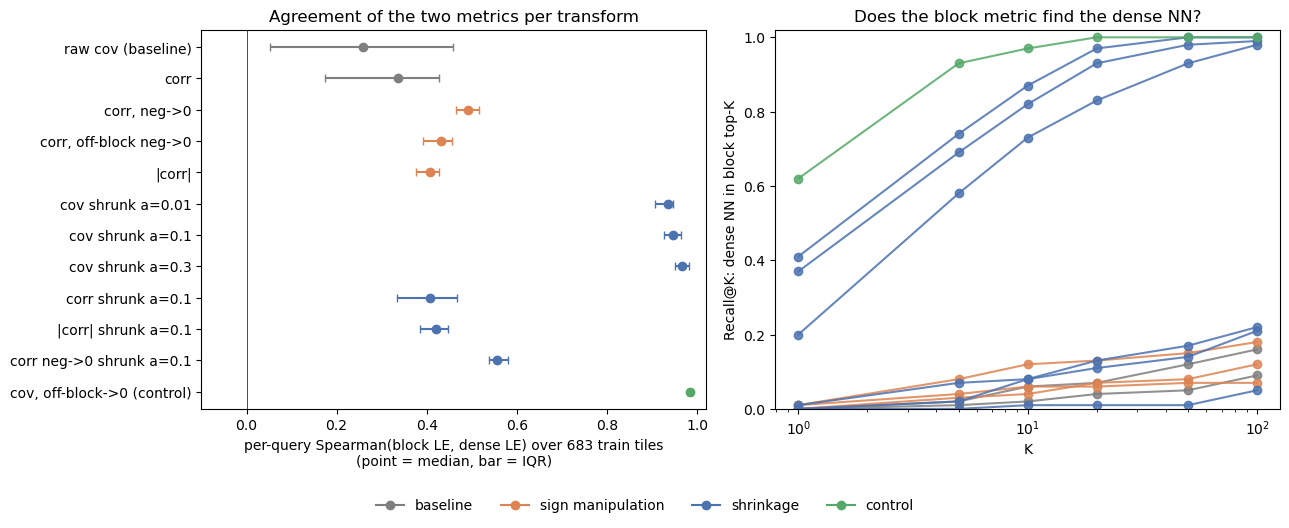

In [6]:
GROUPS = {
    "baseline": ["raw cov (baseline)", "corr"],
    "sign manipulation": ["corr, neg->0", "corr, off-block neg->0", "|corr|"],
    "shrinkage": ["cov shrunk a=0.01", "cov shrunk a=0.1", "cov shrunk a=0.3",
                  "corr shrunk a=0.1", "|corr| shrunk a=0.1", "corr neg->0 shrunk a=0.1"],
    "control": ["cov, off-block->0 (control)"],
}
colors = dict(zip(GROUPS, ["#7f7f7f", "#DD8452", "#4C72B0", "#55A868"]))
order = [v for g in GROUPS.values() for v in g]
group_of = {v: g for g, vs in GROUPS.items() for v in vs}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
ax = axes[0]
y = np.arange(len(order))[::-1]
for yi, v in zip(y, order):
    r = summary.loc[v]
    ax.errorbar(r["rho_median"], yi, xerr=[[r["rho_median"] - r["rho_q25"]], [r["rho_q75"] - r["rho_median"]]],
                fmt="o", color=colors[group_of[v]], capsize=3)
ax.set_yticks(y); ax.set_yticklabels(order)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlim(-0.1, 1.02)
ax.set_xlabel("per-query Spearman(block LE, dense LE) over 683 train tiles\n(point = median, bar = IQR)")
ax.set_title("Agreement of the two metrics per transform")

ax = axes[1]
for v in order:
    ax.plot(recall.columns, recall.loc[v], marker="o", color=colors[group_of[v]], alpha=0.85)
ax.set_xscale("log"); ax.set_ylim(0, 1.02)
ax.set_xlabel("K"); ax.set_ylabel("Recall@K: dense NN in block top-K")
ax.set_title("Does the block metric find the dense NN?")

handles = [plt.Line2D([], [], color=c, marker="o", ls="-", label=g) for g, c in colors.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### One example query: block vs. dense distance to every train tile

The query shown is the one with the median baseline ρ (chosen by that rule, not by eye). Each panel's x and y
axes use that variant's own units.

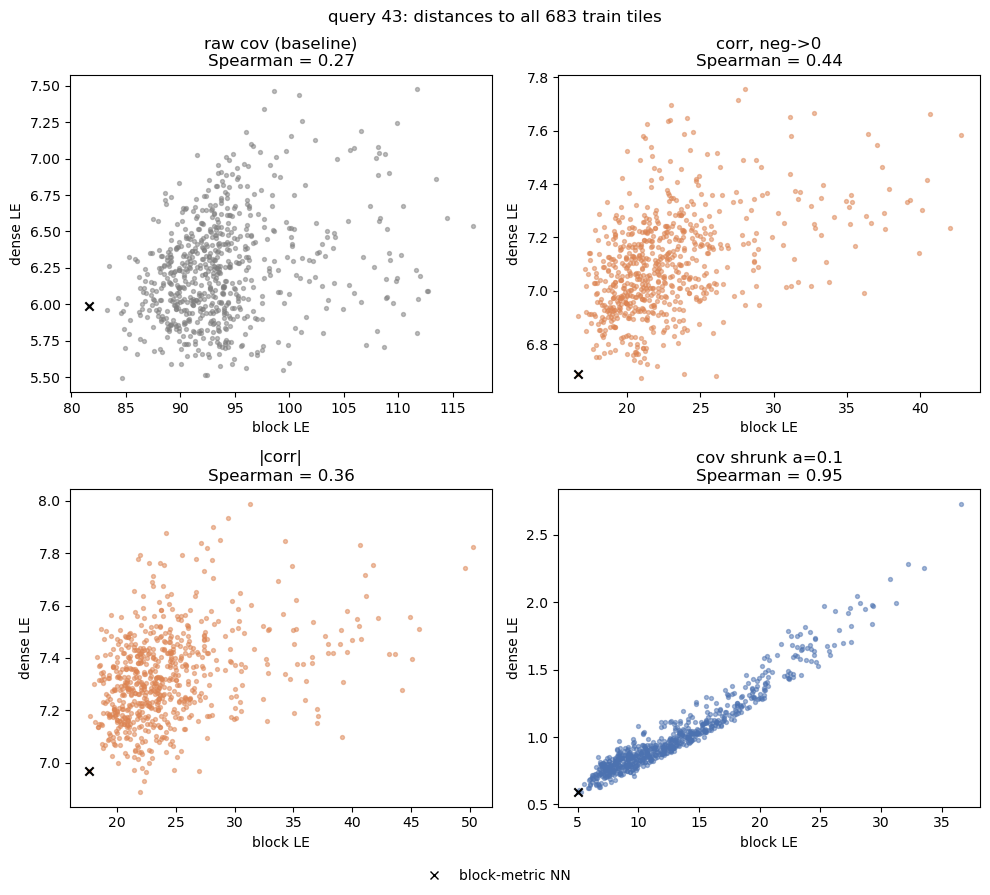

In [7]:
rho_base = np.array([stats.spearmanr(store["raw cov (baseline)"][0][i], store["raw cov (baseline)"][1][i]).statistic
                     for i in range(nq)])
q_ex = int(np.argsort(rho_base)[nq // 2])
panels = ["raw cov (baseline)", "corr, neg->0", "|corr|", "cov shrunk a=0.1"]
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, v in zip(axes.ravel(), panels):
    block, dense = store[v]
    ax.scatter(block[q_ex], dense[q_ex], s=8, alpha=0.5, color=colors[group_of[v]])
    ax.scatter(block[q_ex].min(), dense[q_ex][block[q_ex].argmin()], marker="x", color="k")
    ax.set_title(f"{v}\nSpearman = {stats.spearmanr(block[q_ex], dense[q_ex]).statistic:.2f}")
    ax.set_xlabel("block LE"); ax.set_ylabel("dense LE")
fig.legend(handles=[plt.Line2D([], [], marker="x", color="k", ls="", label="block-metric NN")],
           loc="lower center", frameon=False)
fig.suptitle(f"query {q_ex}: distances to all {len(train)} train tiles")
fig.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## 4. What is the baseline dense metric actually measuring?

If the ε floor dominates, the dense distance should mostly reflect whether two tiles have similar rank, i.e. a similar
cell count, and the floor eigen-directions should carry most of `‖ΔL‖²`.

The floor share is approximate. It is `1 − ‖ΔL′‖²/‖ΔL‖²`, where `L′` sets the log of every floor eigenvalue to 0
instead of −13.8.

In [8]:
block0, dense0 = store["raw cov (baseline)"]
nd = np.abs(n_test[:, None] - n_train[None, :])
print("per-query Spearman across train tiles (baseline):")
print(f"  dense LE vs |n_query - n_train| : {np.mean([stats.spearmanr(dense0[i], nd[i]).statistic for i in range(nq)]):+.3f}")
print(f"  block LE vs n_train             : {np.mean([stats.spearmanr(block0[i], n_train).statistic for i in range(nq)]):+.3f}")
print(f"Spearman(query cell count, dense-NN cell count): {stats.spearmanr(n_test, n_train[dense0.argmin(1)]).statistic:.3f}")
print("median cells -- block NN:", np.median(n_train[block0.argmin(1)]), "| dense NN:", np.median(n_train[dense0.argmin(1)]),
      "| all train:", np.median(n_train))

shares = []
for i in range(nq):
    j = block0[i].argmin()
    wq, Vq = np.linalg.eigh(test[i]); wt, Vt = np.linalg.eigh(train[j])
    lq, lt = np.log(np.maximum(wq, FLOOR)), np.log(np.maximum(wt, FLOOR))
    tot = np.sum(((Vq * lq) @ Vq.T - (Vt * lt) @ Vt.T) ** 2)
    kept = np.sum(((Vq * np.where(wq < 10 * FLOOR, 0, lq)) @ Vq.T - (Vt * np.where(wt < 10 * FLOOR, 0, lt)) @ Vt.T) ** 2)
    shares.append(1 - kept / tot)
print(f"share of dense ||dlog||^2 from floor eigen-directions (query vs block NN): mean {np.mean(shares):.2f}, min {np.min(shares):.2f}")

summary[["offblock_log_energy", "blockNN_median_cells", "denseNN_median_cells"]].loc[
    ["raw cov (baseline)", "cov shrunk a=0.1", "corr", "corr shrunk a=0.1", "corr, neg->0", "|corr|"]].round(2)

per-query Spearman across train tiles (baseline):
  dense LE vs |n_query - n_train| : +0.629
  block LE vs n_train             : -0.624
Spearman(query cell count, dense-NN cell count): 0.922
median cells -- block NN: 161.0 | dense NN: 124.0 | all train: 126.0


share of dense ||dlog||^2 from floor eigen-directions (query vs block NN): mean 0.90, min 0.77


,offblock_log_energy,blockNN_median_cells,denseNN_median_cells
variant,,,
raw cov (baseline),0.35,161.0,124.0
cov shrunk a=0.1,0.06,132.5,130.5
corr,0.88,165.0,176.5
corr shrunk a=0.1,0.77,165.0,38.0
"corr, neg->0",0.89,165.0,183.0
|corr|,0.89,165.0,183.0


## 5. Findings

The numbers below are from the run saved in this notebook; the CSVs sit next to it.

**The ε floor from rank deficiency is the main driver, not negative entries.**
- Every tile's 377×377 covariance comes from ≤ 199 cells. It has 179–351 eigenvalues at the 1e-6 floor (median 252).
  Only 32 of 377 genes have non-zero variance in every tile.
- Those floor directions carry about 90% of the baseline dense `‖ΔL‖²`. Dense LE therefore mostly measures whether two
  tiles are equally rank-deficient: the dense NN's cell count tracks the query's (Spearman 0.92).
- The block metric is floor-affected too. 13 of 18 blocks are rank-deficient in a typical tile, mostly because of
  zero-variance genes. It prefers large tiles: the block NN has a median of 161 cells vs. 126 overall.
- Mild shrinkage toward `mean(diag)·I` removes most of the gap:

  | variant | ρ | top-1 agree | dense NN in block top-10 |
  |---|---|---|---|
  | raw cov (baseline) | 0.21 | 0% | 6% |
  | shrunk, α = 0.01 | 0.91 | 20% | 73% |
  | shrunk, α = 0.1 | 0.95 | 37% | 82% |

  Shrinkage also removes both cell-count biases (block NN 132 vs. dense NN 130 cells), and the off-block share of
  log-space energy drops from 0.35 to 0.06.

**Sign manipulation helps only a little, and breaks the SPD assumption.**
- Negatives → 0 raises ρ to 0.48; off-block negatives → 0 gives 0.42; |corr| gives 0.40. Top-1 agreement stays ≈ 0%.
- These matrices are no longer PSD: 15–17% of eigenvalues are negative, and the minimum eigenvalue reaches −3 for |corr|. So
  "distance" there depends on the arbitrary eigenvalue clip.
- The modest ρ gain is plausibly the destroyed off-block structure making the dense log more block-local. It does not
  fix the floor.

**Controls.**
- Zeroing the off-block covariance gives ρ = 0.98, and 1.00 with the block metric's aggregation matched. The pipeline is
  sound, and the aggregation difference (sum of norms vs. root-sum-square) accounts for only the remaining ~0.02.
- Given shrinkage, the off-block entries themselves matter little: ρ = 0.95 with them vs. 0.98 without.

**Correlation space is worse, even with shrinkage** (corr ρ = 0.25, shrunk corr ρ = 0.39).
- Dividing by √var inflates genes seen in only a few cells of a tile into full-scale, noisy correlations.
  This puts 77–88% of the log-space energy off-block.
- Part G's "73% of correlation energy off-block" therefore reflects low-count noise amplified by normalization,
  plus the entry-count effect: about 17/18 of the entries are off-block.

**Implication.** The dense ground truth (`compute_ground_truth_whole_matrix`) on raw `_cov_ml` covariances is
dominated by the ridge floor, so it is not a meaningful "true" distance on this data. If a dense reference is needed,
compute it on shrunk covariances; α ≈ 0.01–0.1 already aligns the two metrics. The same shrinkage would also remove the
block metric's large-tile bias.